# **PERCEPTRÓN**
Un perceptrón es un modelo de neurona artificial que funciona como un algoritmo de clasificación binaria que recibe multiples datos de entrada, los pondera, les suma un sesgo y aplica una función de activación para determinar una única salida.

Sobre el algoritmo usado nos preguntamos lo siguiente:

**1.**¿El algoritmo encuentra los parámetros correctos?

<font color="blue">Primero, es importante mencionar que no existe un único $\mathbb{w}$ "correcto", pues lo que se pide es que se satisfaga la condición $y_i(\mathbb{w^T\cdot x_i})>0\ \ \ \forall i$, por lo que cualquier hiperplano que separe los datos tiene los parámetros correctos, esto asumiendo que los datos son linealmente separables, pues de lo contrario el perceptron puede oscilar indefinidamente, no converger o simplemente podría ocurrir que los parámetros correctos no existan.</font>

**2.**¿El algoritmo se detiene en un número finito de pasos?

<font color="blue">La certeza de que el perceptrón llega a una solución en un tiempo finito, se tiene gracias al *Teorema de Convergencia del Perceptrón* que enuncia lo siguiente:</font>

<font color="blue">Para un conjunto de datos $D$, tal que $\max_{(x,y)\in D}\|\mathbb{x}\|_2=R$, que es linealmente separable por algún vector unitario $\mathbb{\hat{w}}$, con margen $\gamma:=\min_{(x,y)\in D}y(\mathbb{\hat{w}\cdot x} )$, el algoritmo del perceptrón converge después de cometer a lo sumo $\Big(\frac{R}{\gamma}\Big)^2$ errores, para cualquier tasa de aprendizaje y cualquier método de muestreo del conjunto de datos.</font>

<font color="blue">Este teorema demostrado por *Albert Novikoff* en $1962$ relaciona el número máximo de errores cometidos por el algoritmo con el radio $R$ que dice qué tan esparcidos están los datos y el margen $\gamma$ que dice qué tan amplia es la separación espacial entre las clases de los datos.</font>

<font color="blue">De la ecuación $\Big(\frac{R}{\gamma}\Big)^2$ se puede concluir lo siguiente:
* Si el margen $\gamma$ es grande (clases muy separadas), la fracción se hace pequeña y el perceptrón necesita cometer pocos errores, es decir, el problema es fácil.
* Si el margen $\gamma$ es pequeño (clases muy cercanas), la fracción se hace grande y el perceptrón necesita cometer cometer muchos  errores, ya que la línea divisoria rebotará de un lado a otro haciendo el problema más complejo.
* Si el radio $R$ es grande (datos muy espaciados), la fracción se hace grande y el perceptrón necesita cometer muchos  errores, puesto que la línea divisoria tiene mucho espacio para moverse haciendo el problema más complejo.
* Si el radio $R$ es pequeño (datos muy "apretados"), la fracción se hace pequeña y el perceptrón necesita cometer pocos  errores, puesto que la línea divisoria tiene poco espacio para moverse haciendo el problema más fácil.
</font>

**3.**¿Por qué funciona?

<font color="blue">El algoritmo funciona porque cada vez que el perceptrón comete un error, la regla de actualización mueve el vector de pesos $\mathbb{w}$ en la dirección correcta para compensar ese error, si da un resultado positivo cuando debería ser negativo, al restar $\mathbb{x}$ hace que el próximo producto sea más pequeño (más negativo), mientras que si da un resultado negativo cuando debería ser positivo, al sumar $\mathbb{x}$ hace que el próximo producto sea más grande (más positivo). Con suficientes iteraciones, estas correcciones geométricas orientan la frontera de decisión hasta que todos los puntos quedan en el lado correcto.</font>



### **Implementación**

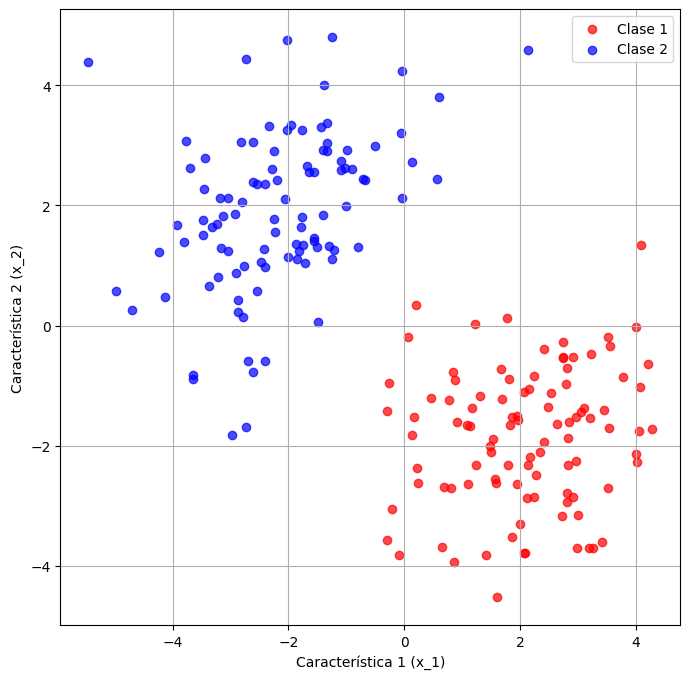

In [ ]:
#Generación de Datos Gaussianos
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)                                  # Semilla

mean1 = [2, -2]                                     # Centro de la distribución
cov1 = [[1.65, 0.5], [0.5, 1.65]]                   # Matriz de covarianza
num_samples = 100
X1 = np.random.multivariate_normal(mean1, cov1, num_samples)

mean2 = [-2, 2]
cov2 = [[1.65, 0.5], [0.5, 1.65]]
X2 = np.random.multivariate_normal(mean2, cov2, num_samples)

plt.figure(figsize=(8, 8))
plt.scatter(X1[:, 0], X1[:, 1], color='red', label='Clase 1', alpha=0.7)
plt.scatter(X2[:, 0], X2[:, 1], color='blue', label='Clase 2', alpha=0.7)
plt.xlabel('Característica 1 (x_1)')
plt.ylabel('Característica 2 (x_2)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Algoritmo
X = np.concatenate((X1, X2), axis=0)
unos = np.ones((X.shape[0], 1)) # Esta columna representa el sesgo (x_0 = 1)
X = np.concatenate((unos, X), axis=1)
y1 = np.ones(len(X1)) # Creamos las etiquetas tomando X1 clase 1 (P) y X2 clase 0 (N)
y2 = np.zeros(len(X2))
y = np.concatenate((y1, y2), axis=0)

w = np.random.rand(X.shape[1])  # Inicializar los pesos (son 3 por el sesgo)
convergencia = False
epocas = 0                      # Contador de épocas

while not convergencia:
    errores = 0                 # Contador de errores en esta época

    for i in range(len(X)):
        if y[i] == 1 and np.dot(w, X[i]) < 0:
            w = w + X[i]
            errores += 1
        elif y[i] == 0 and np.dot(w, X[i]) >= 0:
            w = w - X[i]
            errores += 1

    epocas += 1
    if errores == 0:
        convergencia = True

print(f"¡Convergencia alcanzada en {epocas} épocas!")
print("Pesos finales w:", w)

¡Convergencia alcanzada en 2 épocas!
Pesos finales w: [ 1.86472238  2.40274091 -1.62013062]


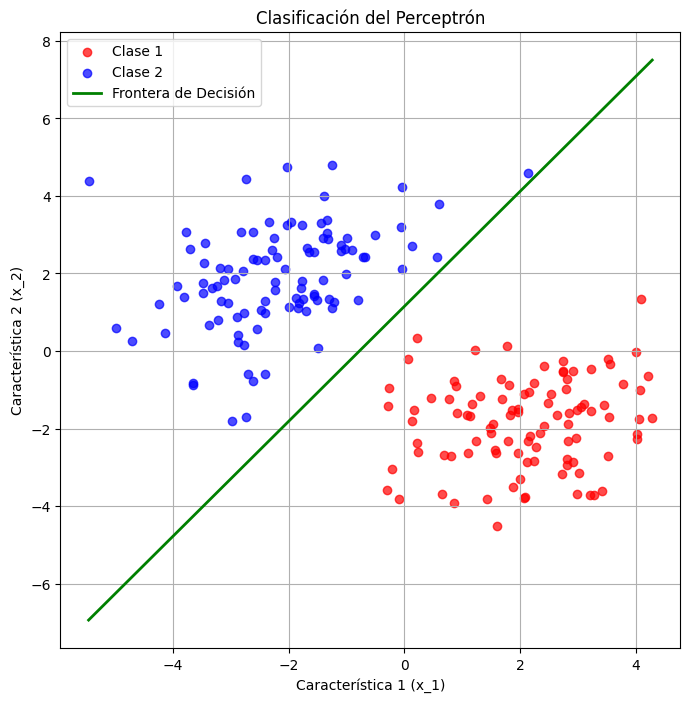

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 8))
plt.scatter(X1[:, 0], X1[:, 1], color='red', label='Clase 1', alpha=0.7)
plt.scatter(X2[:, 0], X2[:, 1], color='blue', label='Clase 2', alpha=0.7)
x_min = np.min(X[:, 1])
x_max = np.max(X[:, 1])
x_valores = np.array([x_min, x_max])
# Despejamos x_2 usando la ecuación matemática
# w[0] es el sesgo, w[1] es el peso de x_1, w[2] es el peso de x_2
y_valores = (-w[0] - w[1] * x_valores) / w[2]


plt.plot(x_valores, y_valores, color='green', linewidth=2, label='Frontera de Decisión')
plt.title('Clasificación del Perceptrón')
plt.xlabel('Característica 1 (x_1)')
plt.ylabel('Característica 2 (x_2)')
plt.legend()
plt.grid(True)
plt.show()

### **Preguntas adicionales**
**Ejercicio 1.2**

Supongamos que usamos un perceptrón para detectar mensajes de spam. Digamos que cada mensaje de correo electrónico está representado por la frecuencia de aparición de palabras clave, y la salida es $+1$ si el mensaje se considera spam.

**a.** ¿Se te ocurren algunas palabras clave que terminen con un peso positivo grande en el perceptrón?

<font color="blue">Tenemos un perceptrón donde las entradas $\mathbb{x}$ son las frecuencias de las palabras en un correo. La salida es $+1$ si el correo es spam y $-1$ si no lo es. Como las frecuencias de las palabras no son negativas $(\mathbb{x}\geq 0)$, un peso positivo $(\mathbb{w>0})$ grande hará que $\mathbb{w}^T\mathbb{x}$ crezca rápidamente hacia el lado positivo de la clase spam. Así el algoritmo aprenderá a asignarle pesos altos a las palabras que suelen aparecer en los correos basura tales como *gratis, oferta, urgente, promoción, dinero y click*.</font>

**b.** ¿Qué hay de las palabras clave que obtendrán un peso negativo?

<font color="blue">De nuevo, como las frecuencias de las palabras no son negativas $(\mathbb{x}\geq 0)$, un peso negativo $(\mathbb{w<0})$ empujará a $\mathbb{w}^T\mathbb{x}$  hacia el lado negativo, alejándolo de la clase spam. Así el algoritmo aprenderá a asignarle pesos negativos a las palabras que suelen aparecer en los correos de confianza tales como *reunión, universidad, tarea, proyecto e informe*.</font>

**c.** ¿Qué parámetro del perceptrón afecta directamente a la cantidad de mensajes límite que terminan siendo clasificados como spam?

<font color="blue">El parámetro es el sesgo $w_0$, pues si es un valor negativo muy grande, se requerirá que un correo tenga muchas palabras con pesos positivos para superar el umbral y ser marcado como spam, mientras que si el sesgo es un valor positivo o cercano a cero, un mensaje con pocas palabras sospechosas cruzará la frontera y será clasificado como spam.</font>

**Ejercicio 1.3**

La regla de actualización de peso tiene la buena interpretación de que se mueve en la dirección de clasificar $x(t)$ correctamente.

**a.** Demuestra que $y(t)\mathbb{w}^T(t)\mathbb{x}(t)< 0$. $\big[$Sugerencia: $\mathbb{x}(t)$ es clasificado erroneamente por $\mathbb{w}(t).\big]$

<font color="blue">DEMOSTRACIÓN:

Sea $y(t)$ la etiqueta real del dato en la iteración $t$, que puede tomar valores $+1$ ó $-1$. El algoritmo clasifica un punto de acuerdo al signo de $\mathbb{w}^T(t)\mathbb{x}(t)$, entonces se pueden tener dos casos:</font>

<font color="blue">- Si la etiqueta real es positiva $(y(t)=+1)$ y el perceptrón se equivoca, es decir, su predicción es negativa $(\mathbb{w}^T(t)\mathbb{x}(t)< 0)$ al operar se obtiene $y(t)\mathbb{w}^T(t)\mathbb{x}(t)< 0$.</font>

<font color="blue">- Si la etiqueta real es negativa $(y(t)=-1)$ y el perceptrón se equivoca, es decir, su predicción es positiva $(\mathbb{w}^T(t)\mathbb{x}(t)> 0)$ al operar se obtiene $y(t)\mathbb{w}^T(t)\mathbb{x}(t)< 0$.

Por lo tanto, en ambos casos de error el producto de la etiqueta real por el valor de la predicción es siempre estrictamente menor que cero.$\tag*{$\square$}$</font>


**b.** Demuestra que $y(t)\mathbb{w}^T(t+1)\mathbb{x}(t)>y(t)\mathbb{w}^T(t)\mathbb{x}(t)$

<font color="blue">DEMOSTRACIÓN:

Sea $y(t)$ la etiqueta real del dato en la iteración $t$, que puede tomar valores $+1$ ó $-1$, con la regla de actualización $\mathbb{w}(t+1)=\mathbb{w}(t)+y(t)\mathbb{x}(t)$ en el perceptrón, entonces se tiene:
\begin{equation}
\begin{split}
y(t)\mathbb{w}^T(t+1)\mathbb{x}(t) & = y(t)\big(\mathbb{w}(t)+y(t)\mathbb{x}(t)\big)^T\mathbb{x}(t) \\
 & = y(t)\Big[\big(\mathbb{w}^T(t)+y(t)\mathbb{x}^T(t)\big)\mathbb{x}(t)\Big] \\
 & = y(t)\Big[\mathbb{w}^T(t)\mathbb{x}(t)+y(t)\mathbb{x}^T(t)\mathbb{x}(t)\Big] \\
 & = y(t)\mathbb{w}^T(t)\mathbb{x}(t)+y(t)^2\mathbb{x}^T(t)\mathbb{x}(t) \\
 & = y(t)\mathbb{w}^T(t)\mathbb{x}(t)+(1)\|\mathbb{x}(t)\|^2 \\
 & = y(t)\mathbb{w}^T(t)\mathbb{x}(t)+\|\mathbb{x}(t)\|^2 \\
 \end{split}
\end{equation}
Luego como $\|\mathbb{x}(t)\|^2\geq0$, se puede concluir que $y(t)\mathbb{w}^T(t+1)\mathbb{x}(t)>y(t)\mathbb{w}^T(t)\mathbb{x}(t)$.$\tag*{$\square$}$
</font>

**c.** En lo que respecta a la clasificación de $\mathbb{x}(t)$, argumente que el paso de $\mathbb{w}(t)$ a $\mathbb{w}(t+1)$ es un paso "en la dirección correcta".

<font color="blue"> Siguiendo la idea del literal **(a)** sabemos que para que un punto esté clasificado correctamente debe ocurrir que $y(t)\mathbb{w}^T(t)\mathbb{x}(t)>0$, además en el literal **(b)** probamos que luego de la actualización de los pesos, el nuevo valor es estrictamente mayor que el anterior. Por lo tanto, la actualización envía el resultado iteración tras iteración cada vez más hacia números positivos, lo que constituye un paso en la dirección correcta para corregir el error de clasificación.
</font>